# DS4: Ensemble Kalman filter (practice)

## Pierre Tandeo, IMT-Atlantique (pierre.tandeo@imt-atlantique.fr)

Data assimilation are numerical methods used in geophysics to mix the information of observations (noted as $y$) and a dynamical model (noted as $\mathcal{M}$). The goal is to estimate the true/hidden state of the system (noted as $x$) at every time step $k$. Usually, data assimilation problems are stated as nonlinear state-space models:

\begin{align*}
x(k) & = \mathcal{M}\left(x(k-1)\right) + \eta(k) \\
y(k) & = \mathcal{H}\left(x(k)\right) + \epsilon(k)
\end{align*}

with $\eta$ and $\epsilon$ some independent white Gaussian noises respectively representing the model and the observation errors. These errors are supposed to be unbiased with covariances noted $Q$ and $R$.

In this practice, we will implement the stochastic version of the Ensemble Kalman Filter (EnKF) to solve the nonlinear state-space model defined above. The idea of the EnKF is simple: use an ensemble of members to estimate empirically the mean and covariance of the state at each time step.

Before working with a nonlinear dynamic model $\mathcal{M}$, we suggest to start from the linear example of the previous practice and see the equivalence with the linear Kalman filter.

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


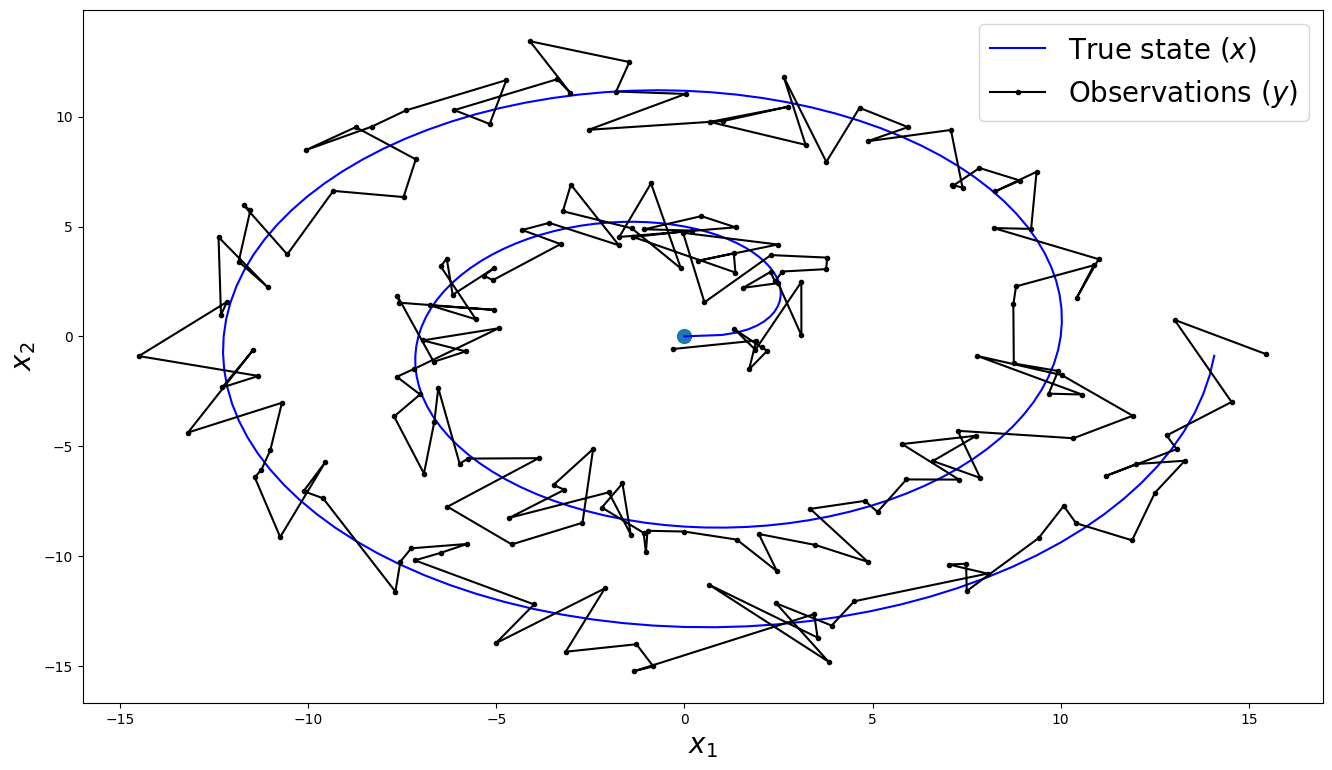

In [59]:
%pylab inline
pylab.rcParams['figure.figsize'] = (16.0, 9.0)

### parameters
n     = 4 # state size
p     = 2 # observation size
nb    = 200 # number of times
time  = array(range(nb)) # time vector
var_Q = 0.1 # error variance of the model (in Kalman)
var_R = 1 # error variance of the observations (in Kalman)
x_0   = zeros((n)) # initial coundition (mean)
P_0   = eye(n,n) # initial coundition (covariance)

### variables
Q      = var_Q*eye(n,n)
R      = var_R*eye(p,p)
x1     = sqrt(time)*cos(2*pi*time/(nb/2)) # true x1 position
x2     = sqrt(time)*sin(2*pi*time/(nb/2)) # true x2 position
x1_dot = x1[time[1:-1]]-x1[time[0:-2]] # true x1 speed
x2_dot = x2[time[1:-1]]-x2[time[0:-2]] # true x2 speed
x1_dot = r_[x1_dot[0], x1_dot, x1_dot[-1]]
x2_dot = r_[x2_dot[0], x2_dot, x2_dot[-1]]

### true state and noisy observations
x = c_[x1, x2, x1_dot, x2_dot].T # true state
y = c_[x1, x2].T + randn(p,nb) # noisy observations

### plot trajectories (true, observed)
plot(x[0,:], x[1,:], 'b', label='True state ($x$)')
plot(y[0,:], y[1,:], '.-k', label='Observations ($y$)')
scatter(x[0,0], x[1,0], 100)
xlabel('$x_1$', fontsize=20)
ylabel('$x_2$', fontsize=20)
legend(fontsize=20)

**1)** Run the linear Kalman filter:

In [60]:
### linear operators of the state-space model
M = array([[1,0,1,0], [0,1,0,1], [0,0,1,0], [0,0,0,1]])
H = array([[1,0,0,0], [0,1,0,0]])

### Kalman initialization
x_f = zeros((n,nb))   # forecast state
P_f = zeros((n,n,nb)) # forecast error covariance matrix
x_a = zeros((n,nb))   # analysed state
P_a = zeros((n,n,nb)) # analysed error covariance matrix

### Kalman filter
x_a[:,0]   = x_0 # initial state
P_a[:,:,0] = P_0 # initial state covariance
for k in range(1,nb): # forward in time
    # prediction step
    x_f[:,k] = M @ x_a[:,k-1]
    P_f[:,:,k] = M @ P_a[:,:,k-1] @ M.T + Q
    # Kalman gain
    K = P_f[:,:,k] @ H.T @ inv(H @ P_f[:,:,k] @ H.T + R)
    # update step
    x_a[:,k] = x_f[:,k] + K @ (y[:,k] - H @ x_f[:,k])
    P_a[:,:,k] = P_f[:,:,k] - K @ H @ P_f[:,:,k]

**2)** Implement the EnKF (prediction step, gain ${\bf K}$, analysis step) using the following formulas, for each member $i=1,\dots,N_e$:
\begin{align*}
    x^f_i(t) &= \mathcal{M} x^a_i(t-1) + \eta_i(t)\\
    y^f_i(t) &= H x^f_i(t) + \epsilon_i(t)\\
    P^f(t) &= \frac{1}{N_e-1} \sum_{i=1}^{N_e} \left( x^f_i(t) - \bar{x}^f(t) \right) \left( x^f_i(t) - \bar{x}^f(t) \right)^\top\\
    K &= P^f(t) H^{T} \left(H P^f(t) H^{T} + R\right)^{-1}\\
    x^a_i(t) &= x^f_i(t) + K \left(y(t) - y^f_i(t)\right)\\
    P^a(t) &= \frac{1}{N_e-1} \sum_{i=1}^{N_e} \left( x^a_i(t) - \bar{x}^a(t) \right) \left( x^a_i(t) - \bar{x}^a(t) \right)^\top\\
\end{align*}

In [61]:
### nonlinear and linear operators of the state-space model
def m(x_past):
    x_future = x_past
    x_future[0] = x_past[0]+x_past[2] ### A CACHER
    x_future[1] = x_past[1]+x_past[3] ### A CACHER
    x_future[2] = x_past[2] ### A CACHER
    x_future[3] = x_past[3] ### A CACHER
    return x_future
H = array([[1,0,0,0], [0,1,0,0]])

### Ensemble Kalman initialization
Ne = 100                   # number of ensembles
x_f_enkf = zeros((n,nb))   # forecast state
P_f_enkf = zeros((n,n,nb)) # forecast error covariance matrix
x_a_enkf = zeros((n,nb))   # analysed state
P_a_enkf = zeros((n,n,nb)) # analysed error covariance matrix

### Ensemble Kalman filter
x_a_enkf_tmp = zeros((n,Ne)) 
x_f_enkf_tmp = zeros((n,Ne))
y_f_enkf_tmp = zeros((p,Ne))
# initial step
for i in range(Ne):
    x_a_enkf_tmp[:,i] = random.multivariate_normal(x_0, P_0)
x_a_enkf[:,0]   = mean(x_a_enkf_tmp,1) # initial state
P_a_enkf[:,:,0] = cov(x_a_enkf_tmp)    # initial state covariance
for k in range(1,nb): # forward in time
    # prediction step
    for i in range(Ne):
        x_f_enkf_tmp[:,i] = m(x_a_enkf_tmp[:,i]) + random.multivariate_normal(zeros(n), Q) ### A CACHER
        y_f_enkf_tmp[:,i] = H @ x_f_enkf_tmp[:,i] + random.multivariate_normal(zeros(p), R) ### A CACHER
    P_f_enkf_tmp = cov(x_f_enkf_tmp) ### A CACHER
    # Kalman gain
    K = P_f_enkf_tmp @ H.T @ inv(H @ P_f_enkf_tmp @ H.T + R) ### A CACHER
    # update step
    for i in range(Ne):
        x_a_enkf_tmp[:,i] = x_f_enkf_tmp[:,i] + K @ (y[:,k] - y_f_enkf_tmp[:,i]) ### A CACHER
    P_a_enkf_tmp = cov(x_a_enkf_tmp) ### A CACHER
    # store results
    x_f_enkf[:,k]   = mean(x_f_enkf_tmp,1)
    P_f_enkf[:,:,k] = P_f_enkf_tmp
    x_a_enkf[:,k]   = mean(x_a_enkf_tmp,1)
    P_a_enkf[:,:,k] = P_a_enkf_tmp

**4)** Compare the results of the linear Kalman filter and the EnKF, changing the number of ensemble members:

RMSE(obs): 1.0682567122322084
RMSE(KF): 0.7576940155773904
RMSE(EnKF): 0.7678779980769538


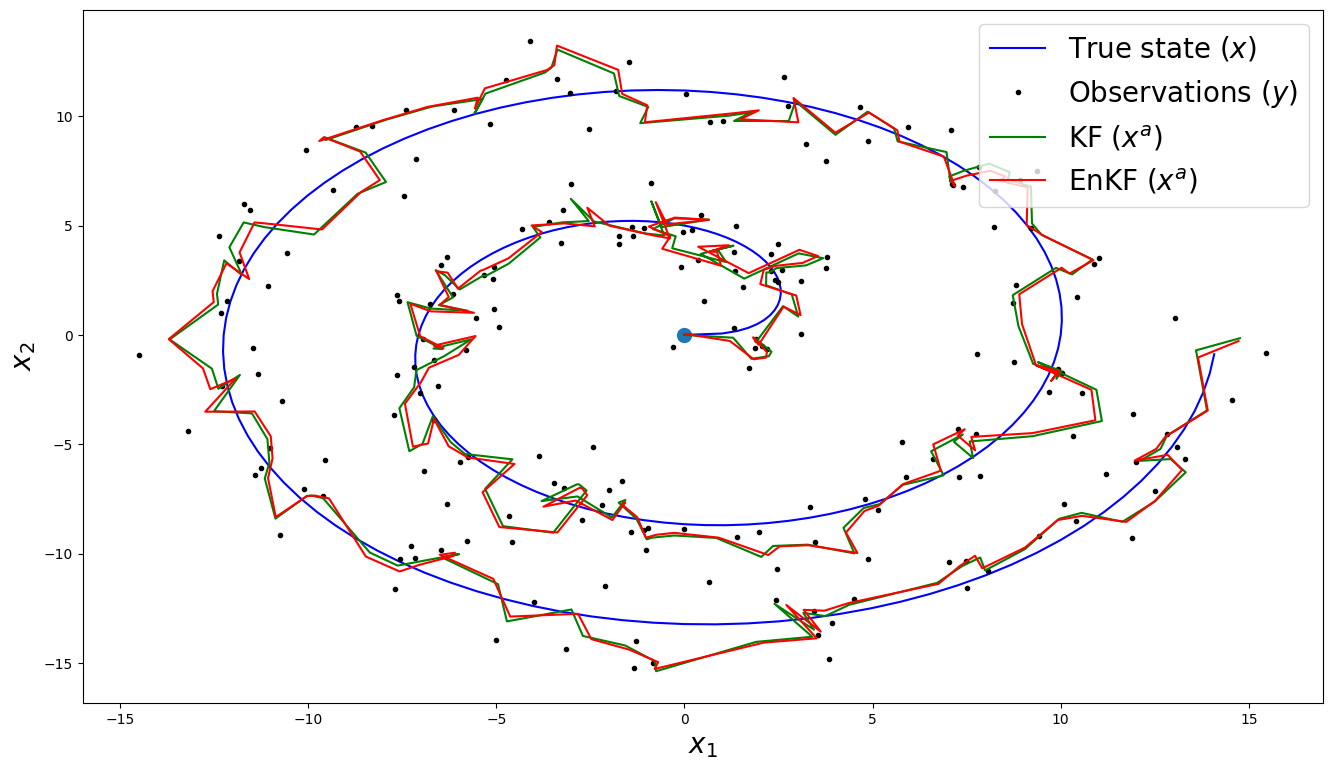

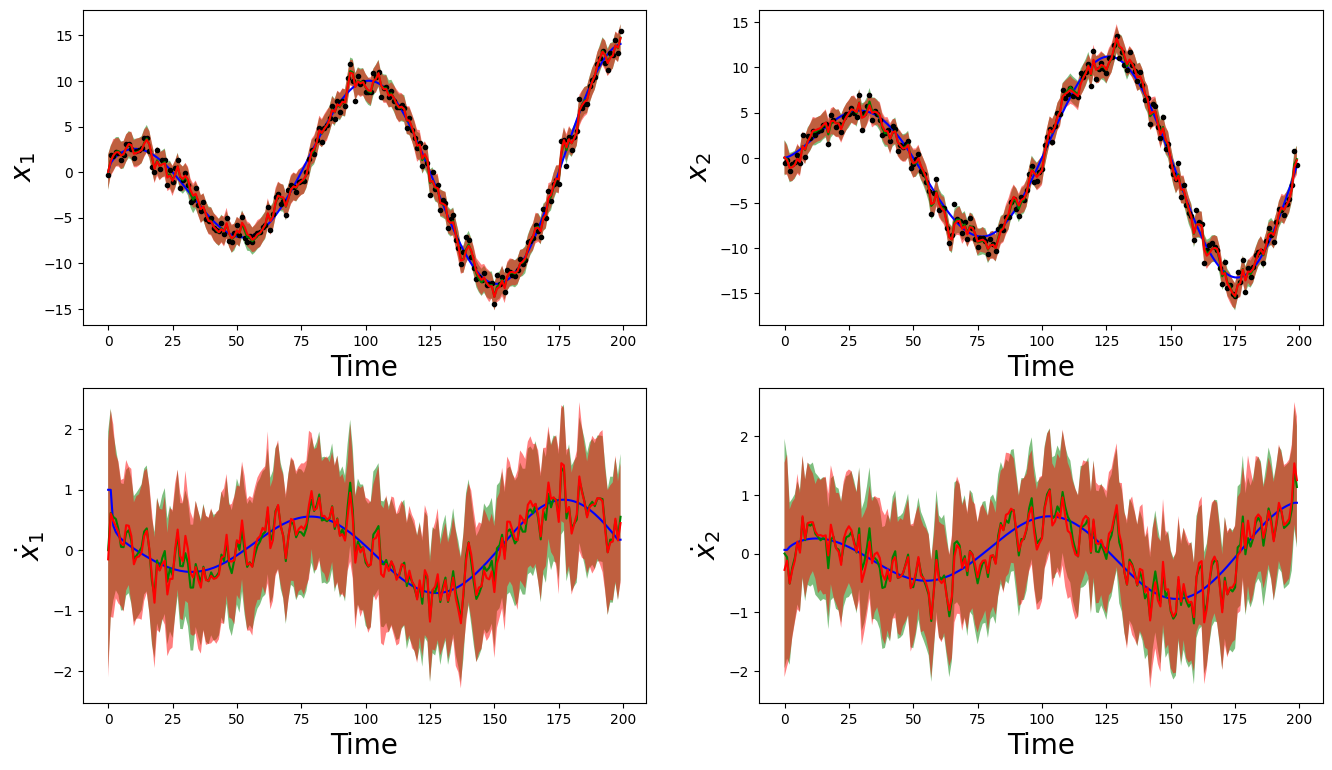

In [62]:
### plot trajectories (true, observed, KF, EnKF)
plot(x[0,:], x[1,:], 'b', label='True state ($x$)')
plot(y[0,:], y[1,:], '.k', label='Observations ($y$)')
plot(x_a[0,:], x_a[1,:], 'g', label='KF ($x^a$)')
plot(x_a_enkf[0,:], x_a_enkf[1,:], 'r', label='EnKF ($x^a$)')
scatter(x[0,0], x[1,0], 100)
xlabel('$x_1$', fontsize=20)
ylabel('$x_2$', fontsize=20)
legend(fontsize=20)

### plot state variables
figure()
y_label=('$x_1$', '$x_2$', '$\dot{x}_1$', '$\dot{x}_2$')
for i in range(4):
    subplot(2,2,i+1)
    plot(time, x[i,:], 'b')
    if ((i==0) or (i==1)):
        plot(time, y[i,:], '.k')
    plot(time, x_a[i,:], 'g')
    fill_between(time, x_a[i,:] - 1.96*sqrt(P_a[i,i,:]), x_a[i,:] + 1.96*sqrt(P_a[i,i,:]), facecolor='green', alpha=0.5)
    plot(time, x_a_enkf[i,:], 'r')
    fill_between(time, x_a_enkf[i,:] - 1.96*sqrt(P_a_enkf[i,i,:]), x_a_enkf[i,:] + 1.96*sqrt(P_a_enkf[i,i,:]), facecolor='red', alpha=0.5)
    xlabel('Time', size=20)
    ylabel(y_label[i], size=20)
    
### compute Root Mean Squared Errors (RMSE) of the positions
print('RMSE(obs):', sqrt(mean((y[range(2),:] - x[range(2),:])**2))) ### A CACHER
print('RMSE(KF):', sqrt(mean((x_a[range(2),:] - x[range(2),:])**2))) ### A CACHER
print('RMSE(EnKF):', sqrt(mean((x_a_enkf[range(2),:] - x[range(2),:])**2))) ### A CACHER

**5)** Now, we suggest to use the EnKF on a highly nonlinear dynamic system $\mathcal{M}$. A classical toy model in data assimilation is the 3-dimensional Lorenz-63 system (see https://en.wikipedia.org/wiki/Lorenz_system). The integration method of this model is given below:

In [63]:
### define the nonlinear dynamic system (Lorenz-63) using the Runge-Kutta integration method
def m(x_past):
    
    # physical parameters
    dT=0.01
    sigma=10
    rho=28
    beta=8/3
    
    # Runge-Kutta (4,5) integration method
    X1 = np.copy(x_past)
    k1 = np.zeros(X1.shape)
    k1[0] = sigma*(X1[1] - X1[0])
    k1[1] = X1[0]*(rho-X1[2]) - X1[1]
    k1[2] = X1[0]*X1[1] - beta*X1[2]
    X2 = np.copy(x_past+k1/2*dT)
    k2 = np.zeros(x_past.shape)
    k2[0] = sigma*(X2[1] - X2[0])
    k2[1] = X2[0]*(rho-X2[2]) - X2[1]
    k2[2] = X2[0]*X2[1] - beta*X2[2]   
    X3 = np.copy(x_past+k2/2*dT)
    k3 = np.zeros(x_past.shape)
    k3[0] = sigma*(X3[1] - X3[0])
    k3[1] = X3[0]*(rho-X3[2]) - X3[1]
    k3[2] = X3[0]*X3[1] - beta*X3[2]
    X4 = np.copy(x_past+k3*dT)
    k4 = np.zeros(x_past.shape)
    k4[0] = sigma*(X4[1] - X4[0])
    k4[1] = X4[0]*(rho-X4[2]) - X4[1]
    k4[2] = X4[0]*X4[1] - beta*X4[2]

    # return the state in the near future
    x_future = x_past + dT/6.*(k1+2*k2+2*k3+k4)
    
    return x_future

Create noisy observations from simulated trajectories of the Lorenz-63 model, assuming that only the first component of the system ($x_1$) is sometimes observed:

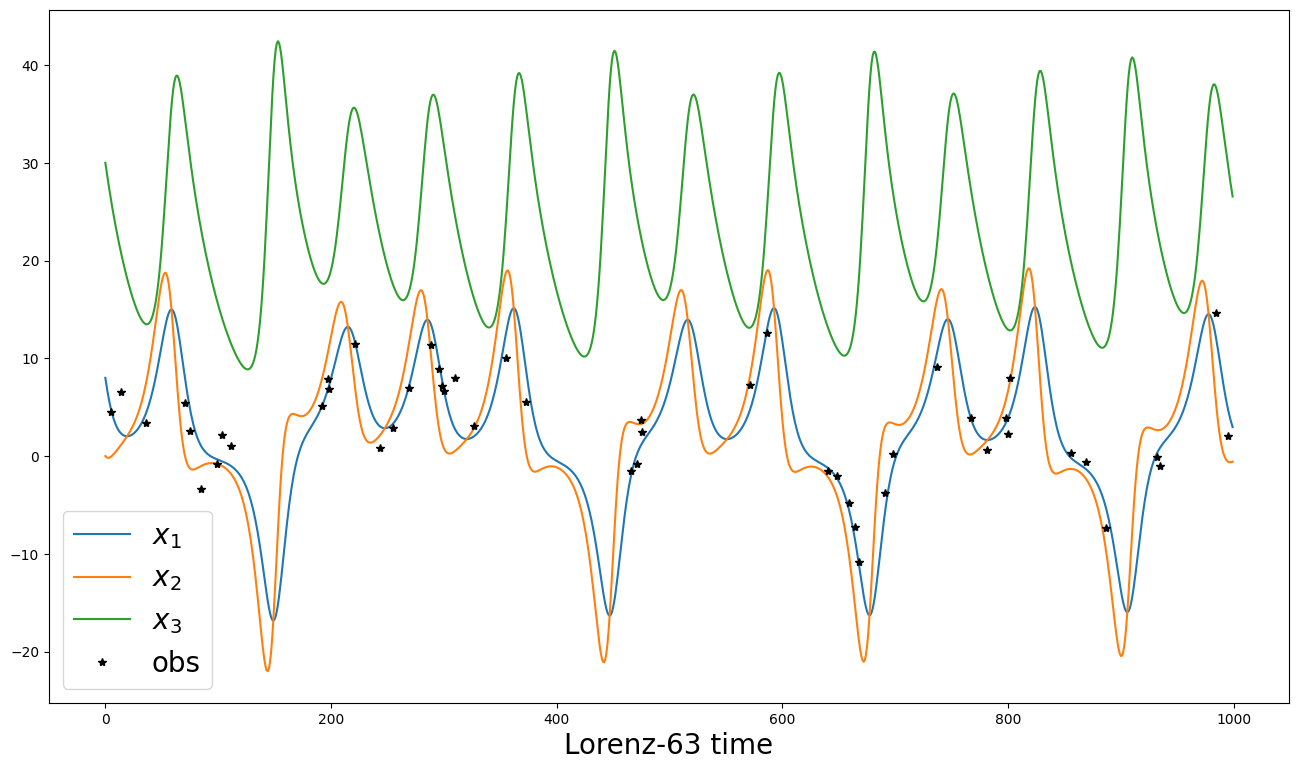

In [64]:
### parameters
n     = 3 # state size
p     = 1 # observation size ### A CACHER
nb    = 1000 # number of times
time  = array(range(nb)) # time vector
var_Q = 0.5 # error variance of the model
var_R = 5 # error variance of the observations
x_0   = zeros((n)) # initial coundition (mean)
P_0   = eye(n,n) # initial coundition (covariance)

### variables
x = zeros((n,nb))
y = zeros((p,nb))
Q = var_Q*eye(n,n)
R = var_R*eye(p,p)

### observation operator
H = array([[1,0,0]]) ### A CACHER

### true state and noisy observations
x[:,0] = array([8,0,30])
for t in range(1,nb):
    x[:,t] = m(x[:,t-1]) # true state ### A CACHER
    y[:,t] = H @ x[:,t] + random.multivariate_normal(zeros(p), R) # noisy observations ### A CACHER
# remove observations    
i_nan = random.choice(range(nb), 3000)
y[:,i_nan] = y[:,i_nan]*nan
    
### plot trajectories (true and observed)
plot(time, x.T)
plot(time, y.T, 'k*')
xlabel('Lorenz-63 time', size=20)
legend(['$x_1$','$x_2$','$x_3$','obs'], prop={'size': 20})

Code and apply the EnKF using the Lorenz-63 model and noisy observations of $x_1$. In this code you will have to take into account the fact that observations are not always available. Therefore, if the observation at a given time $t$ is "nan", the result of $x^a(t)$ and $P^a(t)$ will be $x^f(t)$ and $P^f(t)$.

In [65]:
### Ensemble Kalman initialization
Ne = 100                   # number of ensembles
x_f_enkf = zeros((n,nb))   # forecast state
P_f_enkf = zeros((n,n,nb)) # forecast error covariance matrix
x_a_enkf = zeros((n,nb))   # analysed state
P_a_enkf = zeros((n,n,nb)) # analysed error covariance matrix

################
### A CACHER ###

### Ensemble Kalman filter
x_a_enkf_tmp = zeros((n,Ne)) 
x_f_enkf_tmp = zeros((n,Ne))
y_f_enkf_tmp = zeros((p,Ne))
# initial step
for i in range(Ne):
    x_a_enkf_tmp[:,i] = random.multivariate_normal(x_0, P_0)
x_a_enkf[:,0]   = mean(x_a_enkf_tmp,1) # initial state
P_a_enkf[:,:,0] = cov(x_a_enkf_tmp)    # initial state covariance
for k in range(1,nb): # forward in time
    # prediction step
    for i in range(Ne):
        x_f_enkf_tmp[:,i] = m(x_a_enkf_tmp[:,i]) + random.multivariate_normal(zeros(n), Q)
        y_f_enkf_tmp[:,i] = H @ x_f_enkf_tmp[:,i] + random.multivariate_normal(zeros(p), R)
    P_f_enkf_tmp = cov(x_f_enkf_tmp) ### A CACHER
    # Kalman gain
    K = P_f_enkf_tmp @ H.T @ inv(H @ P_f_enkf_tmp @ H.T + R) ### A CACHER
    # update step
    if(sum(isfinite(y[:,k]))>0): # if observations are available
        for i in range(Ne):
            x_a_enkf_tmp[:,i] = x_f_enkf_tmp[:,i] + K @ (y[:,k] - y_f_enkf_tmp[:,i])
        P_a_enkf_tmp = cov(x_a_enkf_tmp)
    else:
        x_a_enkf_tmp = x_f_enkf_tmp
        P_a_enkf_tmp = P_f_enkf_tmp 
    # store results
    x_f_enkf[:,k]   = mean(x_f_enkf_tmp,1)
    P_f_enkf[:,:,k] = P_f_enkf_tmp
    x_a_enkf[:,k]   = mean(x_a_enkf_tmp,1)
    P_a_enkf[:,:,k] = P_a_enkf_tmp
    
### A CACHER ###
################

Text(0.5, 0, 'Lorenz-63 time')

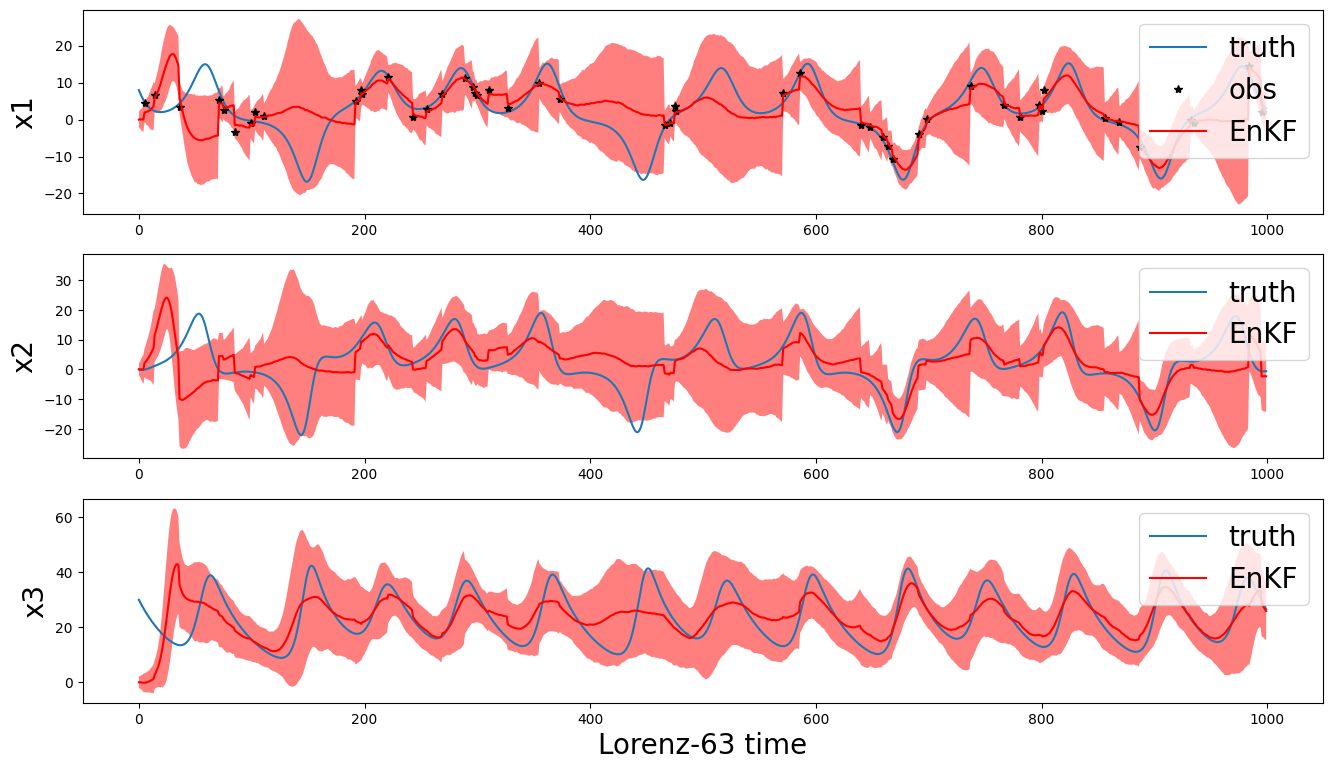

In [66]:
### plot trajectories (true and filtered)
for i in range(3):
    subplot(3,1,i+1)
    plot(time, x[i,:])
    try:
        plot(time, y[i,:], 'k*')  
        plot(time, x_a_enkf[i,:], 'r')
        fill_between(time, x_a_enkf[i,:] - 1.96*sqrt(P_a_enkf[i,i,:]), x_a_enkf[i,:] + 1.96*sqrt(P_a_enkf[i,i,:]), facecolor='red', alpha=0.5)
        ylabel('x' + str(i+1), size=20)
        legend(['truth', 'obs', 'EnKF'], prop={'size': 20}, loc=1)
    except:
        plot(time, x_a_enkf[i,:], 'r')
        fill_between(time, x_a_enkf[i,:] - 1.96*sqrt(P_a_enkf[i,i,:]), x_a_enkf[i,:] + 1.96*sqrt(P_a_enkf[i,i,:]), facecolor='red', alpha=0.5)
        ylabel('x' + str(i+1), size=20)
        legend(['truth', 'EnKF'], prop={'size': 20}, loc=1)
xlabel('Lorenz-63 time', size=20)

**6)** Evaluate the impact of the number of observed components (e.g., $p=2$) and available observations (i.e., number of NaN values) on the quality of the reconstructed trajectories.

In [67]:
### Generate observations and covariance
def generate_observations(p, H, i_nan):
    y = zeros((p,nb))
    R = var_R*eye(p,p) # observation covariance
    for t in range(1,nb):
        y[:,t] = H @ x[:,t] + random.multivariate_normal(zeros(p), R) # noisy observations
    y[:,i_nan] = y[:,i_nan]*nan # remove observations 
    return y, R

In [68]:
### Apply the Ensemble Kalman filter for the Lorenz-63 system
def EnKF_L63(y, R):

    # initialization
    Ne = 100                   # number of ensembles
    x_f_enkf = zeros((n,nb))   # forecast state
    P_f_enkf = zeros((n,n,nb)) # forecast error covariance matrix
    x_a_enkf = zeros((n,nb))   # analysed state
    P_a_enkf = zeros((n,n,nb)) # analysed error covariance matrix
    x_a_enkf_tmp = zeros((n,Ne)) 
    x_f_enkf_tmp = zeros((n,Ne))
    y_f_enkf_tmp = zeros((p,Ne))

    # initial step
    for i in range(Ne):
        x_a_enkf_tmp[:,i] = random.multivariate_normal(x_0, P_0)
    x_a_enkf[:,0]   = mean(x_a_enkf_tmp,1) # initial state
    P_a_enkf[:,:,0] = cov(x_a_enkf_tmp)    # initial state covariance
    for k in range(1,nb): # forward in time
        # prediction step
        for i in range(Ne):
            x_f_enkf_tmp[:,i] = m(x_a_enkf_tmp[:,i]) + random.multivariate_normal(zeros(n), Q)
            y_f_enkf_tmp[:,i] = H @ x_f_enkf_tmp[:,i] + random.multivariate_normal(zeros(p), R)
        P_f_enkf_tmp = cov(x_f_enkf_tmp) ### A CACHER
        # Kalman gain
        K = P_f_enkf_tmp @ H.T @ inv(H @ P_f_enkf_tmp @ H.T + R) ### A CACHER
        # update step
        if(sum(isfinite(y[:,k]))>0): # if observations are available
            for i in range(Ne):
                x_a_enkf_tmp[:,i] = x_f_enkf_tmp[:,i] + K @ (y[:,k] - y_f_enkf_tmp[:,i])
            P_a_enkf_tmp = cov(x_a_enkf_tmp)
        else:
            x_a_enkf_tmp = x_f_enkf_tmp
            P_a_enkf_tmp = P_f_enkf_tmp 
        # store results
        x_f_enkf[:,k]   = mean(x_f_enkf_tmp,1)
        P_f_enkf[:,:,k] = P_f_enkf_tmp
        x_a_enkf[:,k]   = mean(x_a_enkf_tmp,1)
        P_a_enkf[:,:,k] = P_a_enkf_tmp

    return x_a_enkf, P_a_enkf

In [69]:
### Plot the results of the Ensemble Kalman filter for the Lorenz-63 system
def plot_EnKF_L63(x_a_enkf, P_a_enkf):
    for i in range(3):
        subplot(3,1,i+1)
        plot(time, x[i,:])
        try:
            plot(time, y[i,:], 'k*')  
            plot(time, x_a_enkf[i,:], 'r')
            fill_between(time, x_a_enkf[i,:] - 1.96*sqrt(P_a_enkf[i,i,:]), x_a_enkf[i,:] + 1.96*sqrt(P_a_enkf[i,i,:]), facecolor='red', alpha=0.5)
            ylabel('x' + str(i+1), size=20)
            legend(['truth', 'obs', 'EnKF'], prop={'size': 20}, loc=1)
        except:
            plot(time, x_a_enkf[i,:], 'r')
            fill_between(time, x_a_enkf[i,:] - 1.96*sqrt(P_a_enkf[i,i,:]), x_a_enkf[i,:] + 1.96*sqrt(P_a_enkf[i,i,:]), facecolor='red', alpha=0.5)
            ylabel('x' + str(i+1), size=20)
            legend(['truth', 'EnKF'], prop={'size': 20}, loc=1)
    xlabel('Lorenz-63 time', size=20)

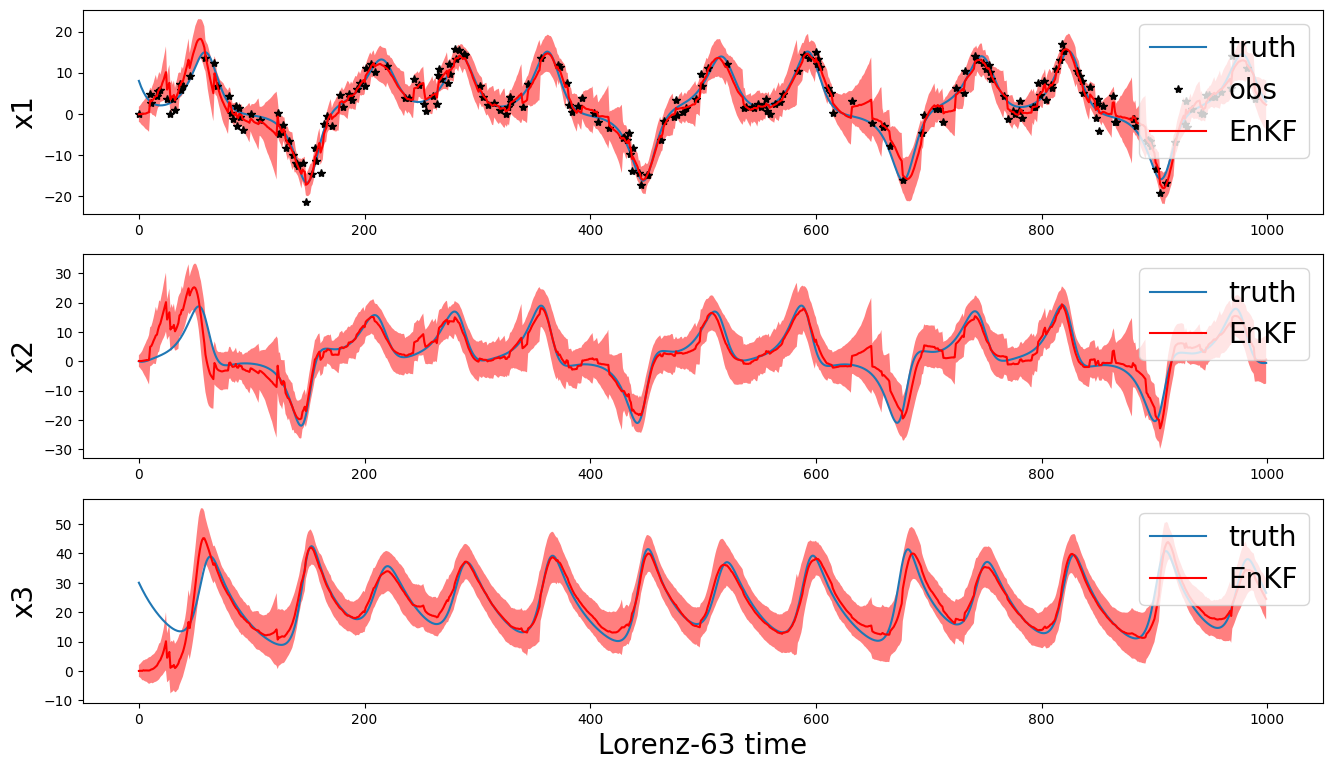

In [70]:
### Exp 0: native experiment
p = 1
H = array([[1,0,0]])
i_nan = random.choice(range(nb), 1500)
y, R = generate_observations(p, H, i_nan)
x_a_enkf, P_a_enkf = EnKF_L63(y, R)
plot_EnKF_L63(x_a_enkf, P_a_enkf)

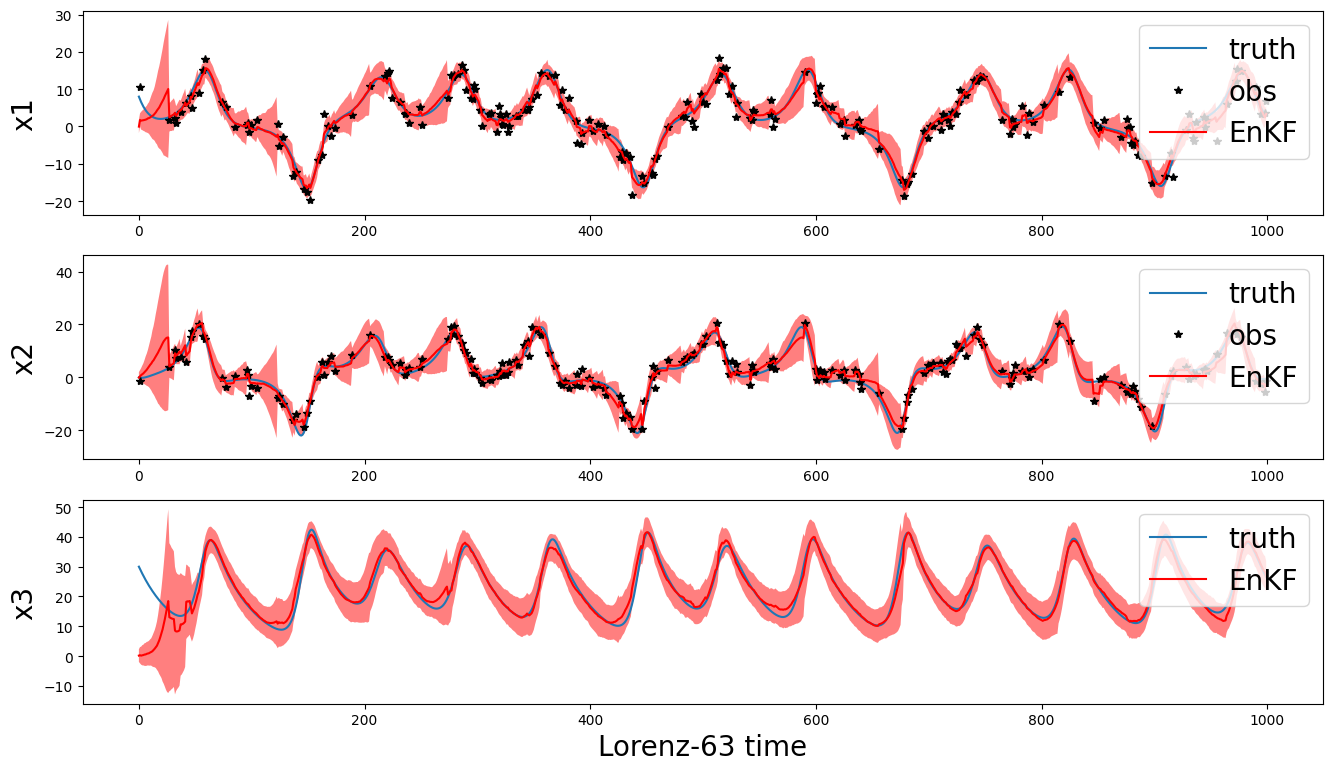

In [71]:
### Exp 1: increasing the number of observed components
p = 2
H = array([[1,0,0], [0,1,0]])
i_nan = random.choice(range(nb), 1500)
y, R = generate_observations(p, H, i_nan)
x_a_enkf, P_a_enkf = EnKF_L63(y, R)
plot_EnKF_L63(x_a_enkf, P_a_enkf)

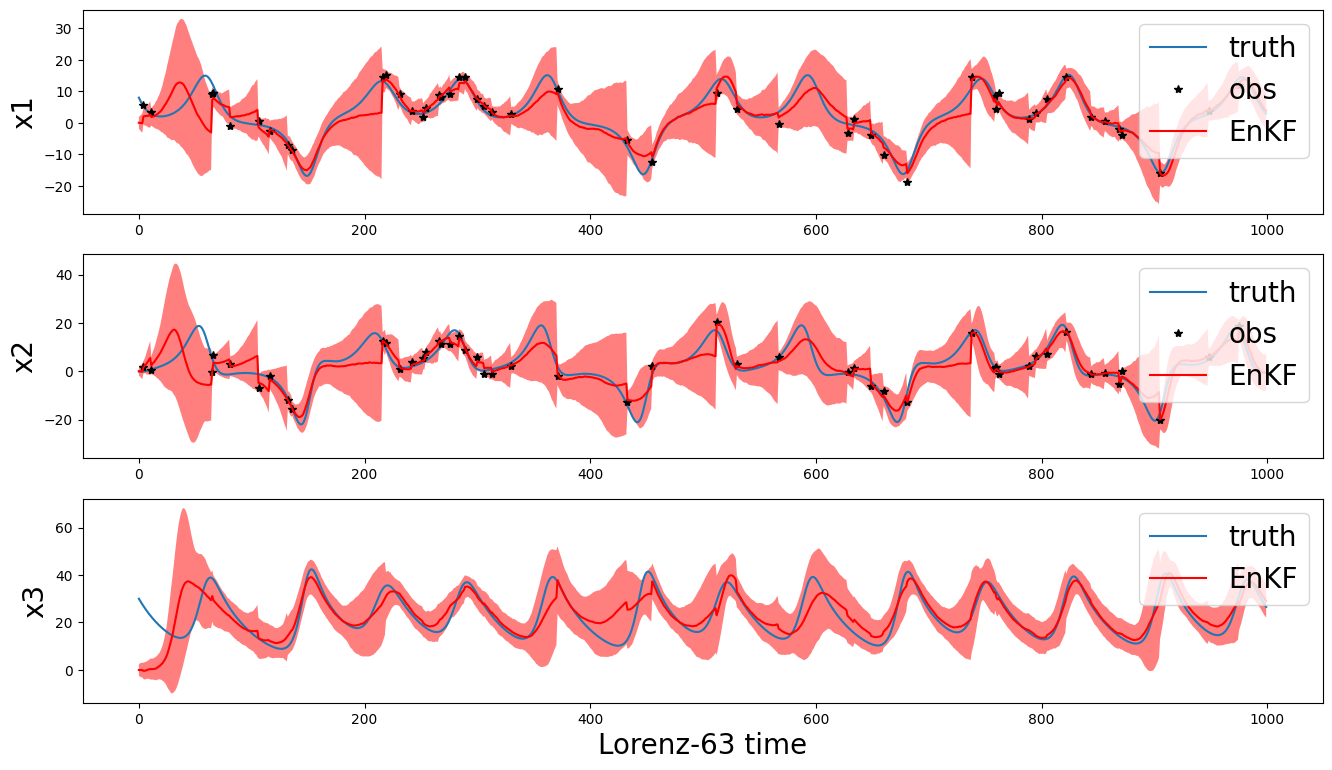

In [72]:
### Exp 2: reducing the number of available observations
p = 2
H = array([[1,0,0], [0,1,0]])
i_nan = random.choice(range(nb), 3000)
y, R = generate_observations(p, H, i_nan)
x_a_enkf, P_a_enkf = EnKF_L63(y, R)
plot_EnKF_L63(x_a_enkf, P_a_enkf)